In [13]:
# LOAD LIBRARIES.
import sys; import os
sys.path.append(os.path.abspath('..'))

%matplotlib inline
import numpy as np
import importlib
import matplotlib.pyplot as plt
plt.style.use('dissertation.mplstyle')

from IPython.display import clear_output

from python import forces, integrators, random_matrix, simulate, densities, plotters
importlib.reload(forces); importlib.reload(integrators); importlib.reload(random_matrix)
importlib.reload(simulate); importlib.reload(densities); importlib.reload(plotters);

---

### Newton Solver

Main questions:
- How does the number of Newton iterations scale as $N$ increases?
- How does the number of CG iterations scale as $N$ increases?
- Is $dt = 1/N$ good enough?

**Run again after implementing both FMM algorithms. Change the data type of arrays to be float!**

In [14]:
# NOTE probably should re-run this so that we track the acceptance rate and also the Newton tolerance...
beta = 2.0; T = 5.0; M = 100; potential_name = "quartic";
N_range = [30, 50, 100, 150, 200, 250, 300, 500]

mean_newton_iters = np.zeros_like(N_range) # CHANGE ALL TO BE FLOAT
mean_cg_iters = np.zeros_like(N_range)
mean_line_search_rejects = np.zeros_like(N_range)

for j, N in enumerate(N_range):
    clear_output(wait = True)
    print(f"Running N = {N}.")

    dt = 1/N; total_steps = int(T/dt);
    init = random_matrix.init_gue_eigenvalues(M, N)

    maimla_pipe = simulate.make_imla_pipeline(N, dt, potential_name, beta, metropolise = True)
    trajectory = simulate.simulate_dbm(init, total_steps, maimla_pipe)

    config = {
        "track_snapshots": False,
        "track_accepts": True,
        "track_newton_info": True
    }

    info = simulate.analyse_trajectory(trajectory, total_steps, **config)
    mean_newton_iters[j] = info["newton_iters"].mean()
    mean_cg_iters[j] = info["mean_cg_iters"].mean()
    mean_line_search_rejects[j] = info["line_search_rejects"].mean()

Running N = 500.


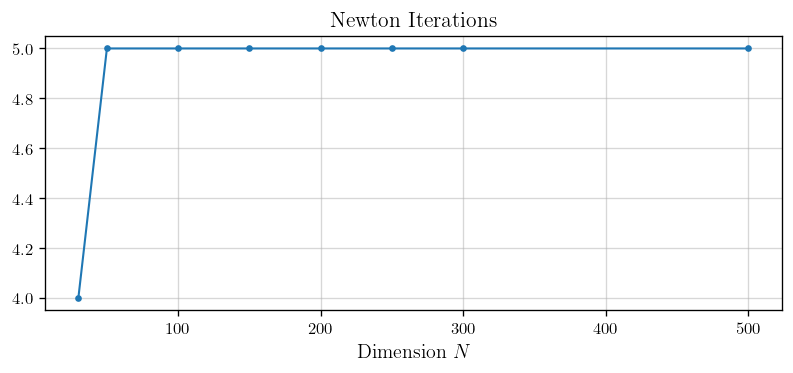

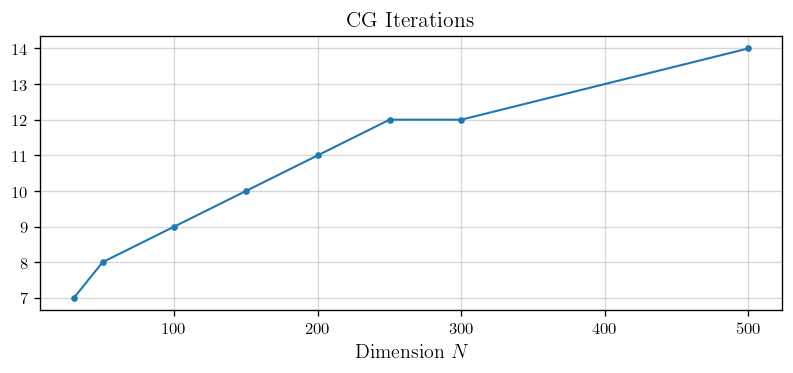

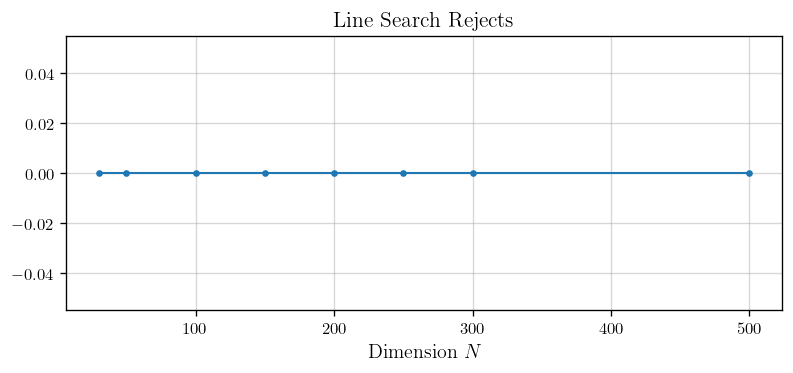

In [15]:
ax_titles = ["Newton Iterations", "CG Iterations", "Line Search Rejects"]
for title, arr in zip(ax_titles, [mean_newton_iters, mean_cg_iters, mean_line_search_rejects]):
    fig, ax = plt.subplots()
    ax.plot(N_range, arr, marker = 'o', markersize = 3)
    ax.set_title(title)
    ax.set_xlabel(r"Dimension $N$"); 

    plt.show()

In [20]:
info["newton_iters"].mean()
# NOTE Change array data type to float!

np.float64(5.942376)

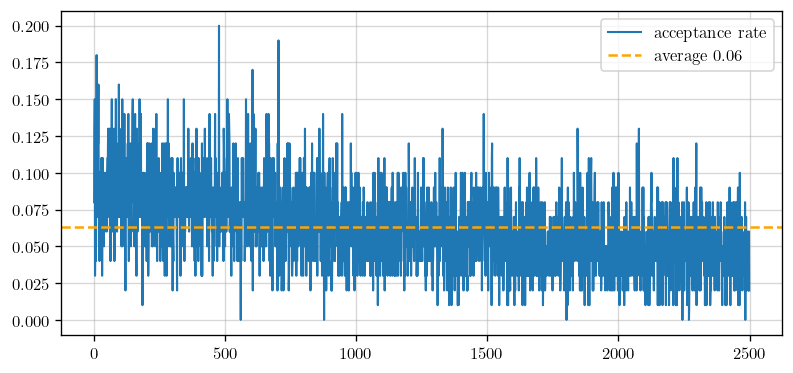

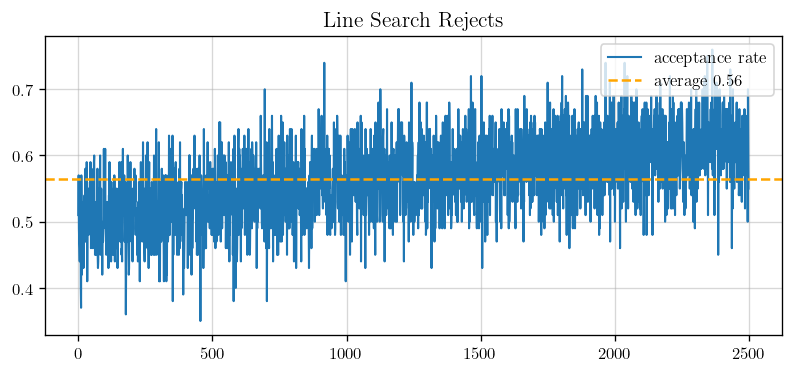

In [23]:
fig, ax = plt.subplots()
plotters.plot_accepts(ax, info["accepts"])
plt.show()

fig, ax = plt.subplots()
plotters.plot_accepts(ax, info["line_search_rejects"])
ax.set_title("Line Search Rejects")
plt.show()


---

In [25]:
beta = 2.0; T = 2.0; M = 10; potential_name = "quartic";
N = 120; dt = 1/N; total_steps = int(T/dt);

maimla_pipe = simulate.make_imla_pipeline(N, dt, potential_name, beta, metropolise = True)
trajectory = simulate.simulate_dbm(init, total_steps, maimla_pipe)

config = {
    "track_snapshots": False,
    "track_accepts": True,
    "track_newton_info": True
}

info = simulate.analyse_trajectory(trajectory, total_steps, **config)

# Run again but with different dt.
N = 300; dt = 1/(2*N); total_steps = int(T/dt);
maimla_pipe = simulate.make_imla_pipeline(N, dt, potential_name, beta, metropolise = True)
trajectory = simulate.simulate_dbm(init, total_steps, maimla_pipe)

config = {
    "track_snapshots": False,
    "track_accepts": True,
    "track_newton_info": True
}

info_2 = simulate.analyse_trajectory(trajectory, total_steps, **config)

SystemError: CPUDispatcher(<function imla_step at 0x000002821893F740>) returned a result with an exception set

In [ ]:
fig, axes = plt.subplots(1, 2, figsize = (8, 3))
ax1, ax2 = axes
plotters.plot_accepts(ax1, info["accepts"])
plotters.plot_accepts(ax2, info["line_search_rejects"])

ax1.set_title("Acceptance Rate (dt = 1/N)")
ax2.set_title("Line Search Rejection Rate (dt = 1/N)")

plt.show()

fig, axes = plt.subplots(1, 2, figsize = (8, 3))
ax1, ax2 = axes
plotters.plot_accepts(ax1, info_2["accepts"])
plotters.plot_accepts(ax2, info_2["line_search_rejects"])

ax1.set_title("Acceptance Rate (dt = 1/2N)")
ax2.set_title("Line Search Rejection Rate (dt = 1/2N)")

plt.show()